Packages

In [281]:
import pandas as pd
import matplotlib.pyplot as plt
import os


In [282]:
file_path = "../9 - Data/4_14_26_BANG_BANG_TESTS/BANG_TEST_7.csv"  # change if needed
df = pd.read_csv(file_path)

# === Plot export settings ===
save_plots = True
output_folder = "../8 - Plots"
os.makedirs(output_folder, exist_ok=True)

Parse Data

In [283]:
# === Split rows properly ===
ai_df = df[df["DEV2_ai_time"].notna()][
    ["DEV2_ai_time", "DEV2_ai_0", "DEV2_ai_1", "DEV2_ai_2"]
].copy()

state_df = df[df["DEV2_do_state_time"].notna()][
    [
        "DEV2_do_state_time",
        "DEV2_do_0_0_state",
        "DEV2_do_0_1_state",
        "DEV2_do_0_2_state"
    ]
].copy()

# === Shared zero time ===
t0 = min(ai_df["DEV2_ai_time"].min(), state_df["DEV2_do_state_time"].min())

# Convert time to seconds starting at 0
ai_df["time_s"] = (ai_df["DEV2_ai_time"] - t0) / 1e9
state_df["time_s"] = (state_df["DEV2_do_state_time"] - t0) / 1e9

# === Channel lists ===
ai_cols = ["DEV2_ai_0", "DEV2_ai_1", "DEV2_ai_2"]
state_cols = [
    "DEV2_do_0_0_state",
    "DEV2_do_0_1_state",
    "DEV2_do_0_2_state"
]

# === Legend names ===
ai_labels = {
    "DEV2_ai_0": "Feed Press.",
    "DEV2_ai_1": "Top Tank",
    "DEV2_ai_2": "Bot. Tank"
}

state_labels = {
    "DEV2_do_0_0_state": "TPC_1",
    "DEV2_do_0_1_state": "TPC_2",
    "DEV2_do_0_2_state": "Bleed"
}

Plot Data

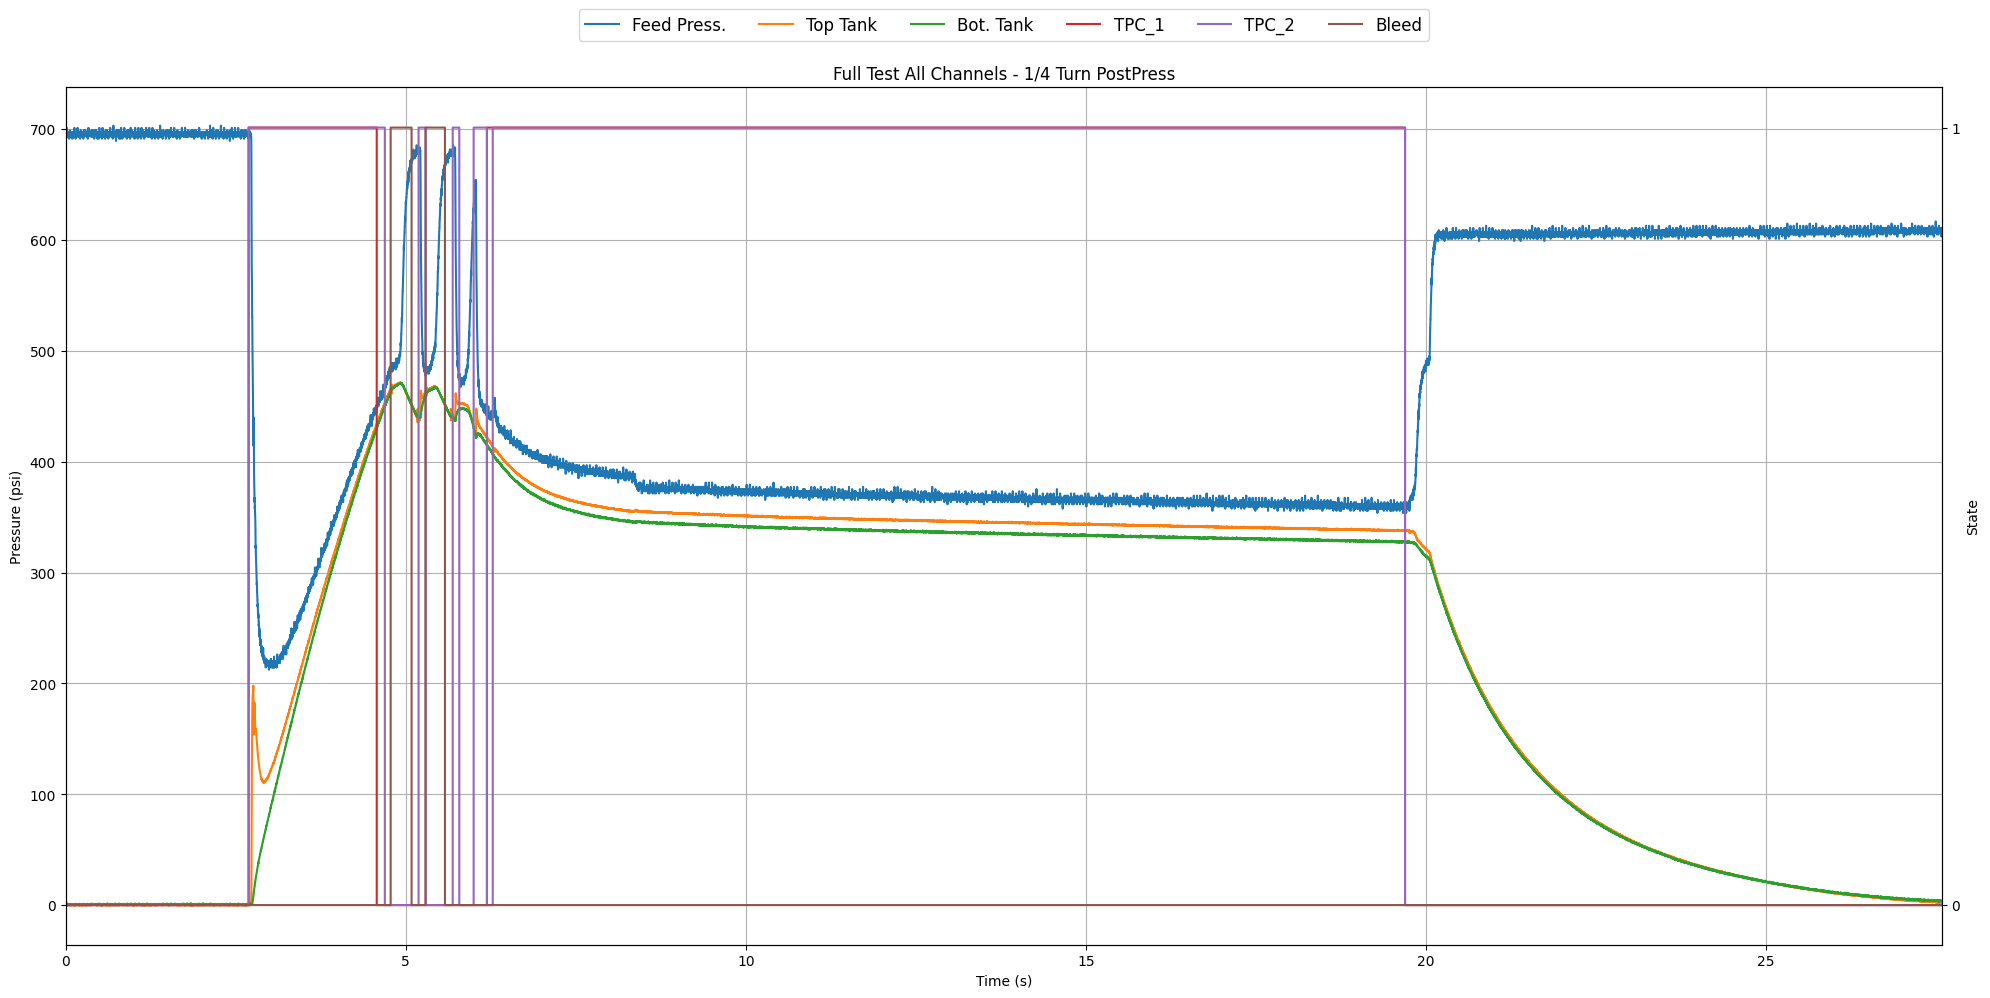

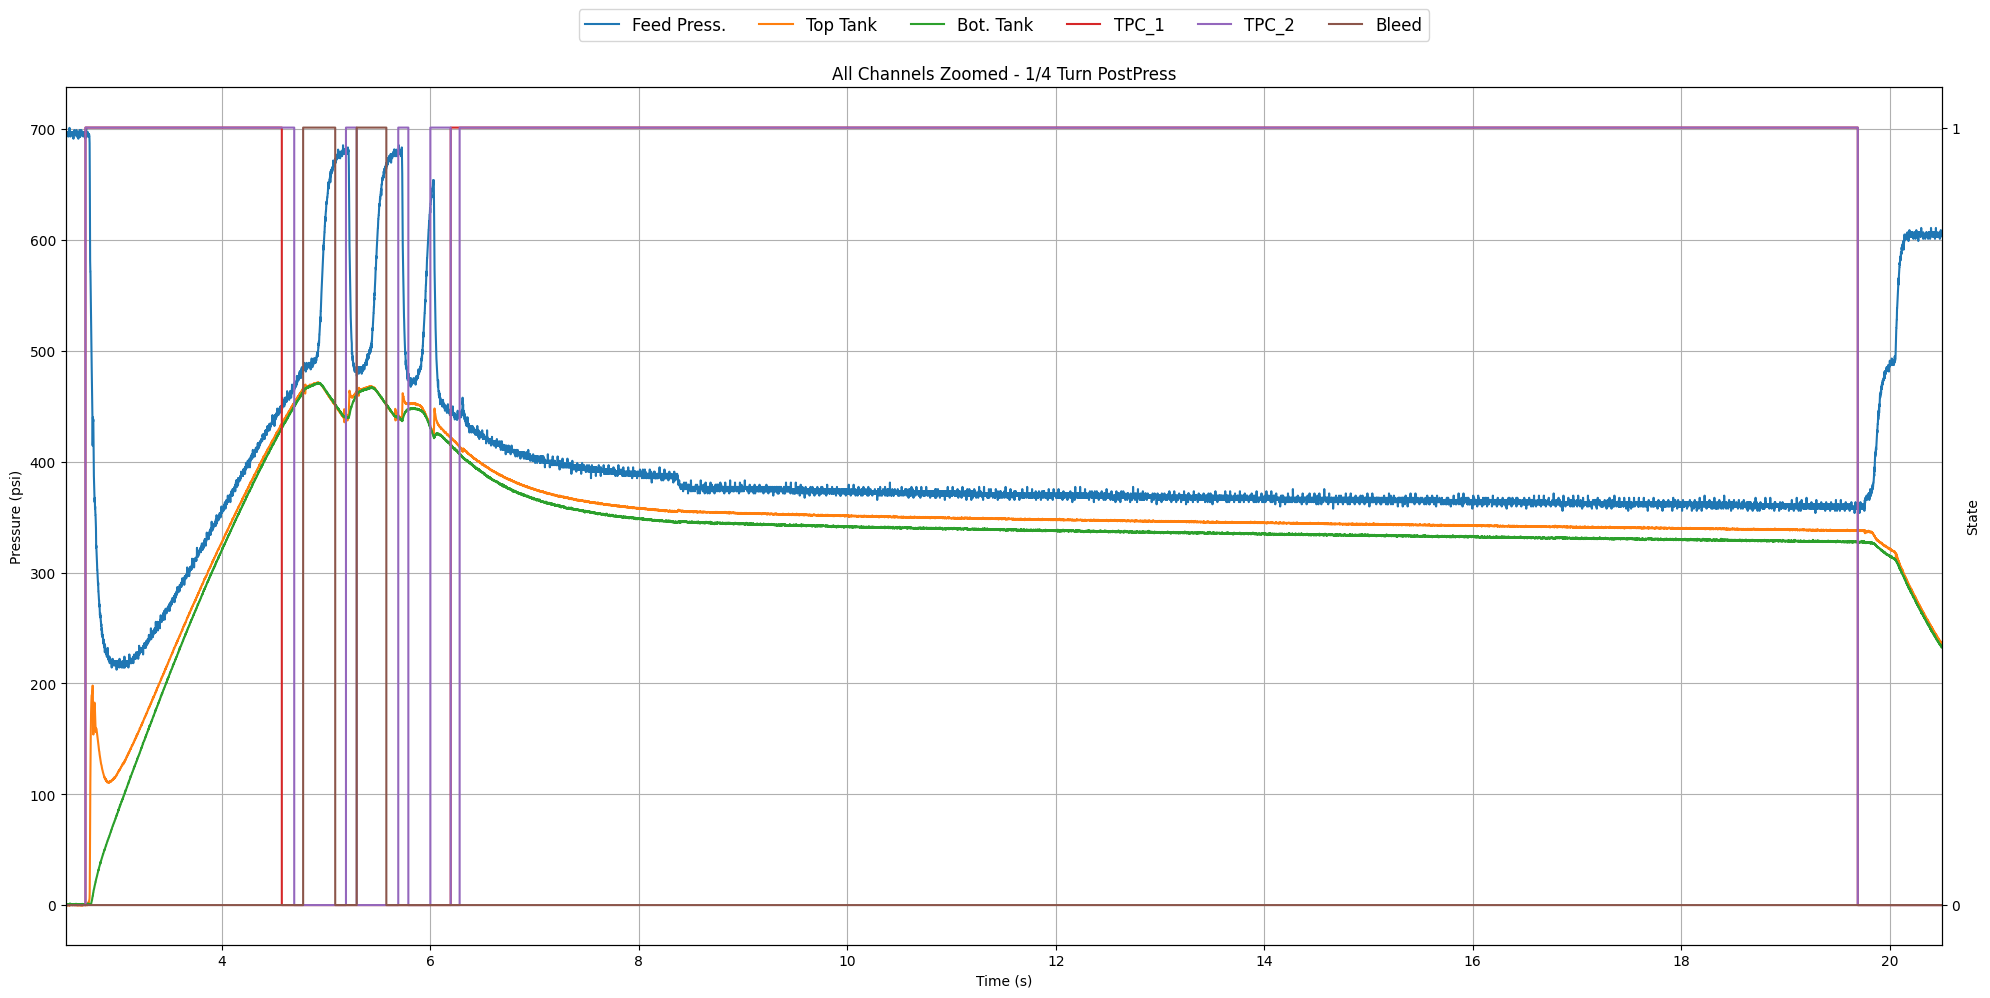

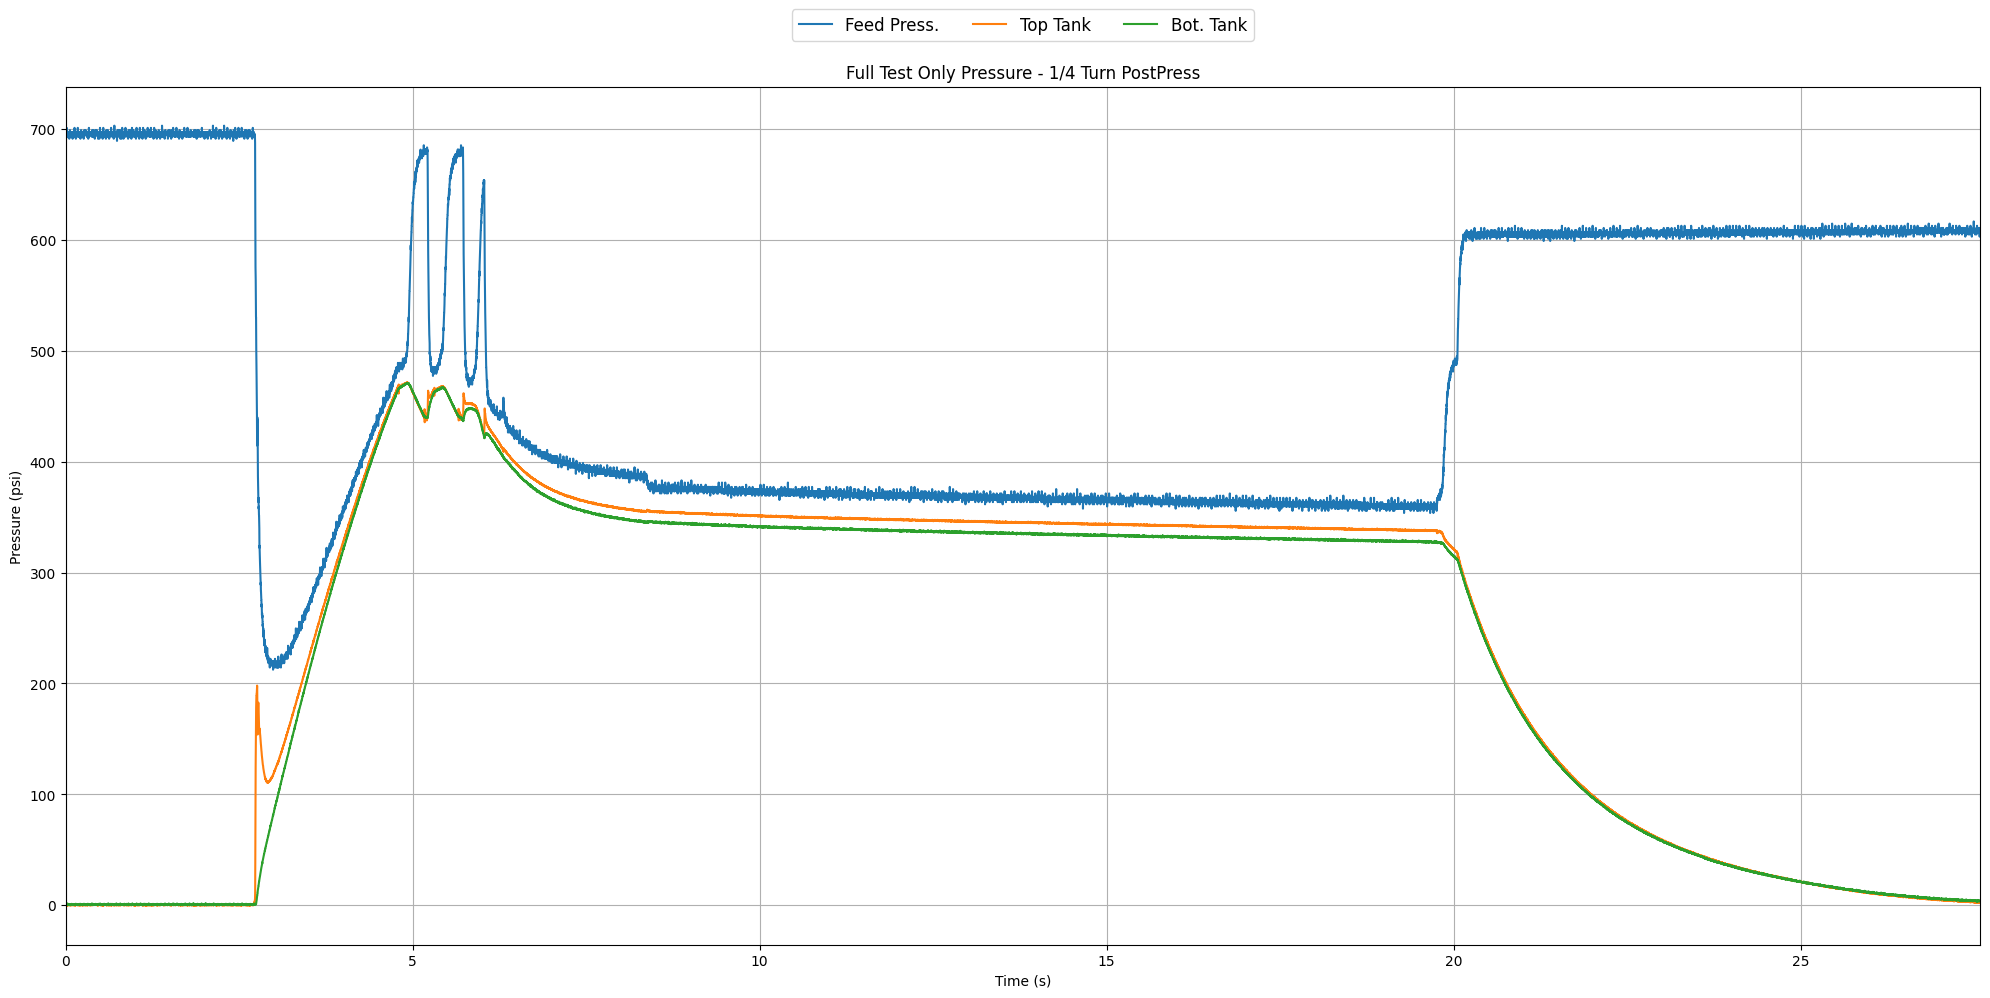

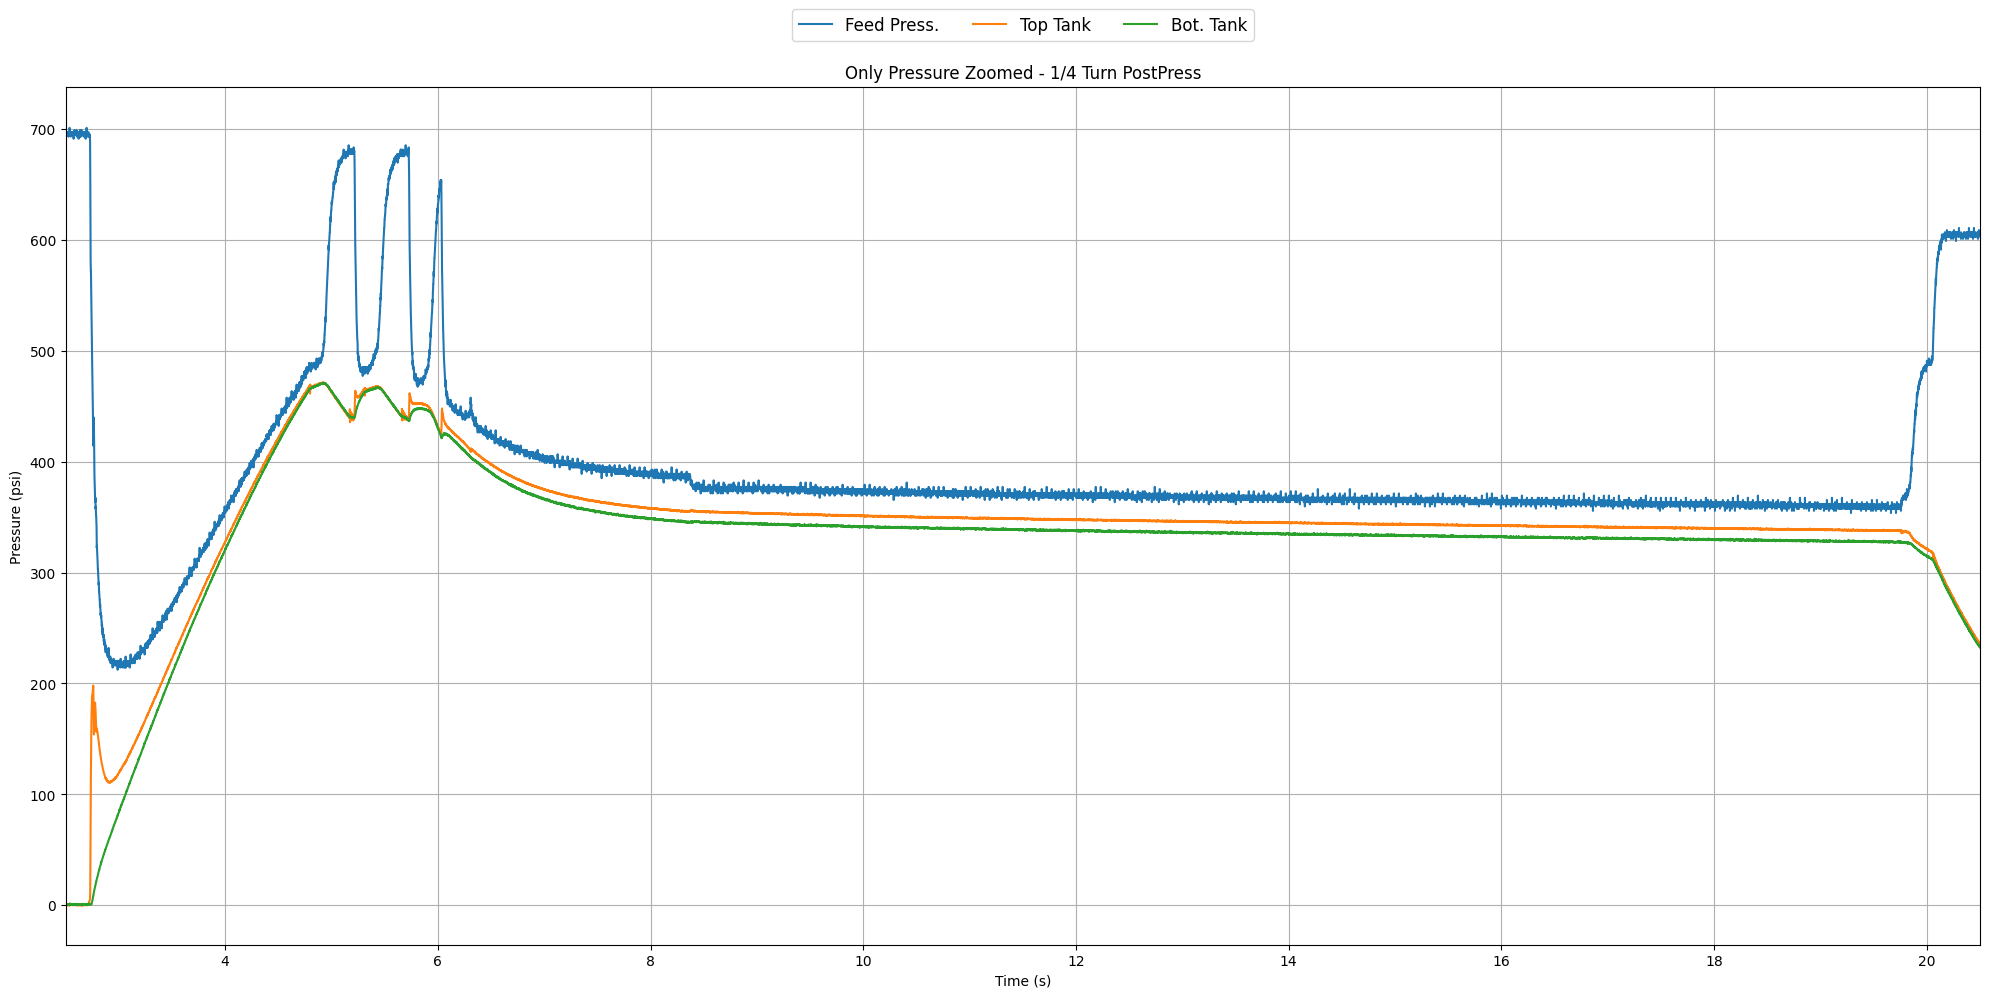

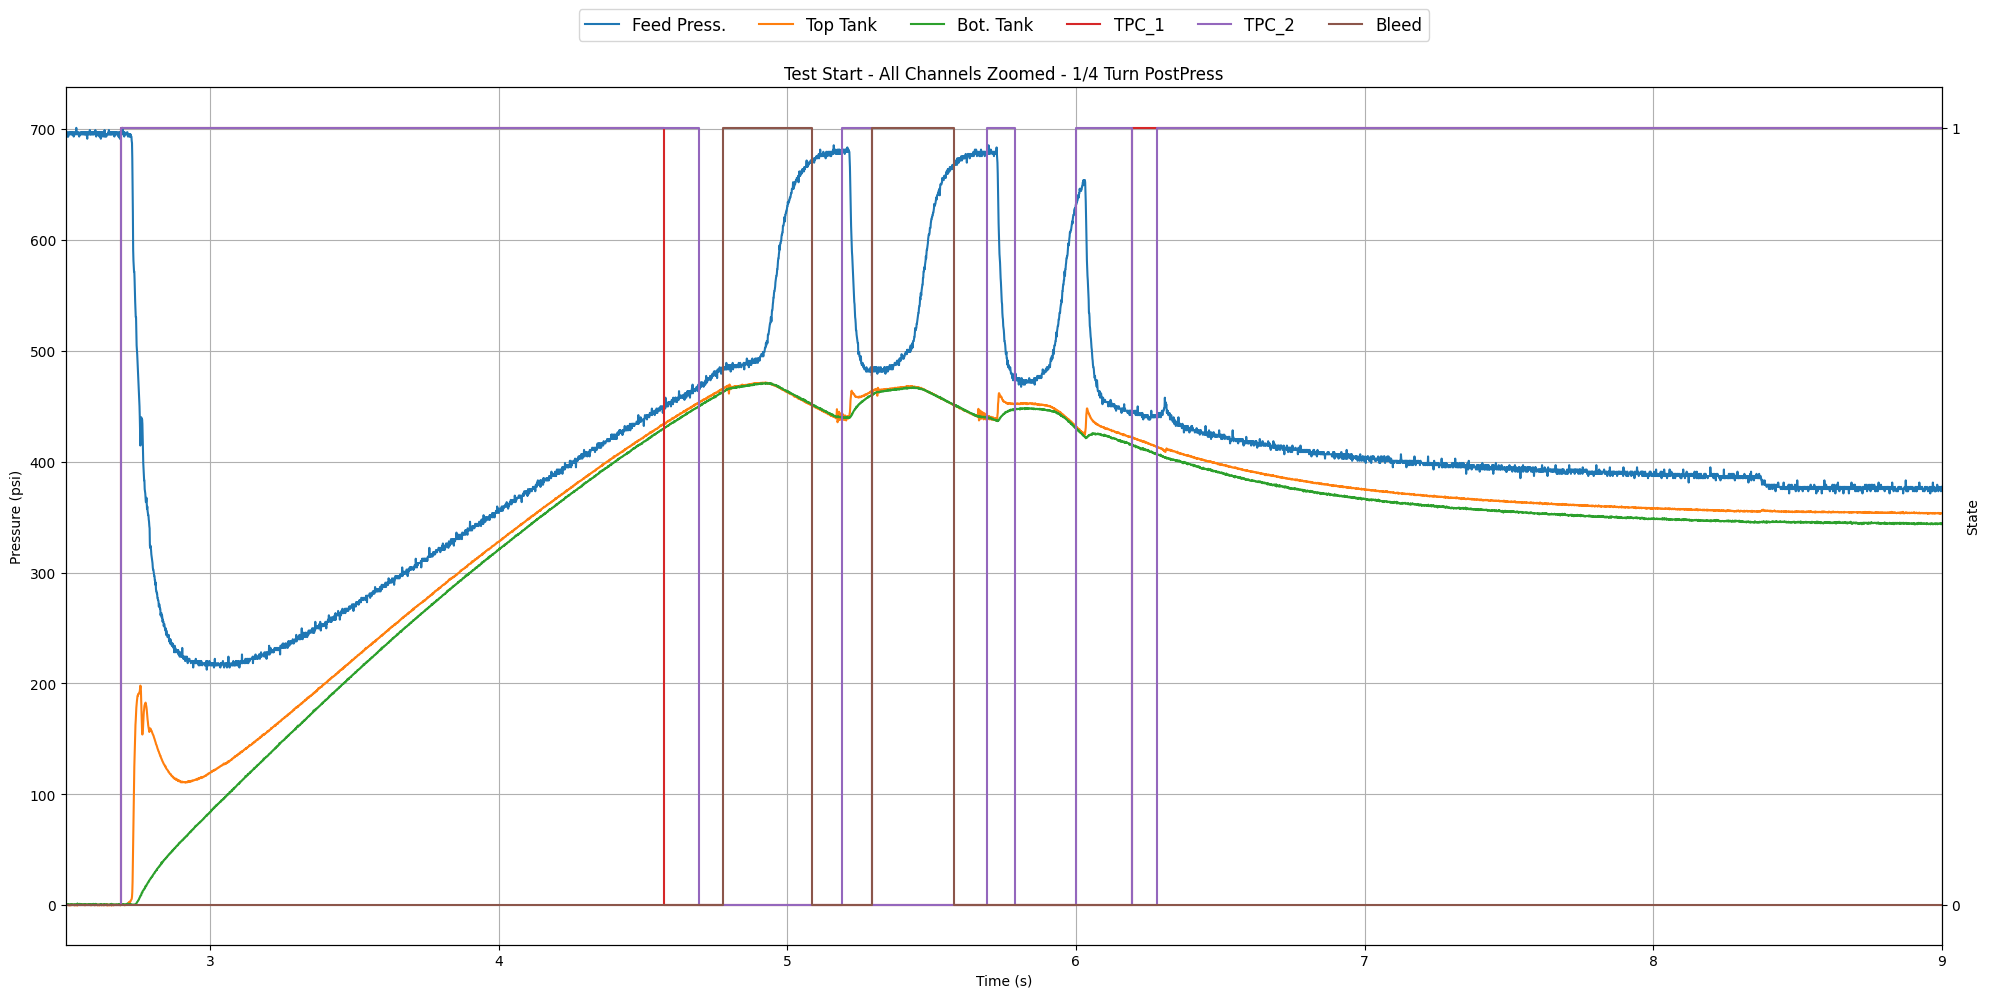

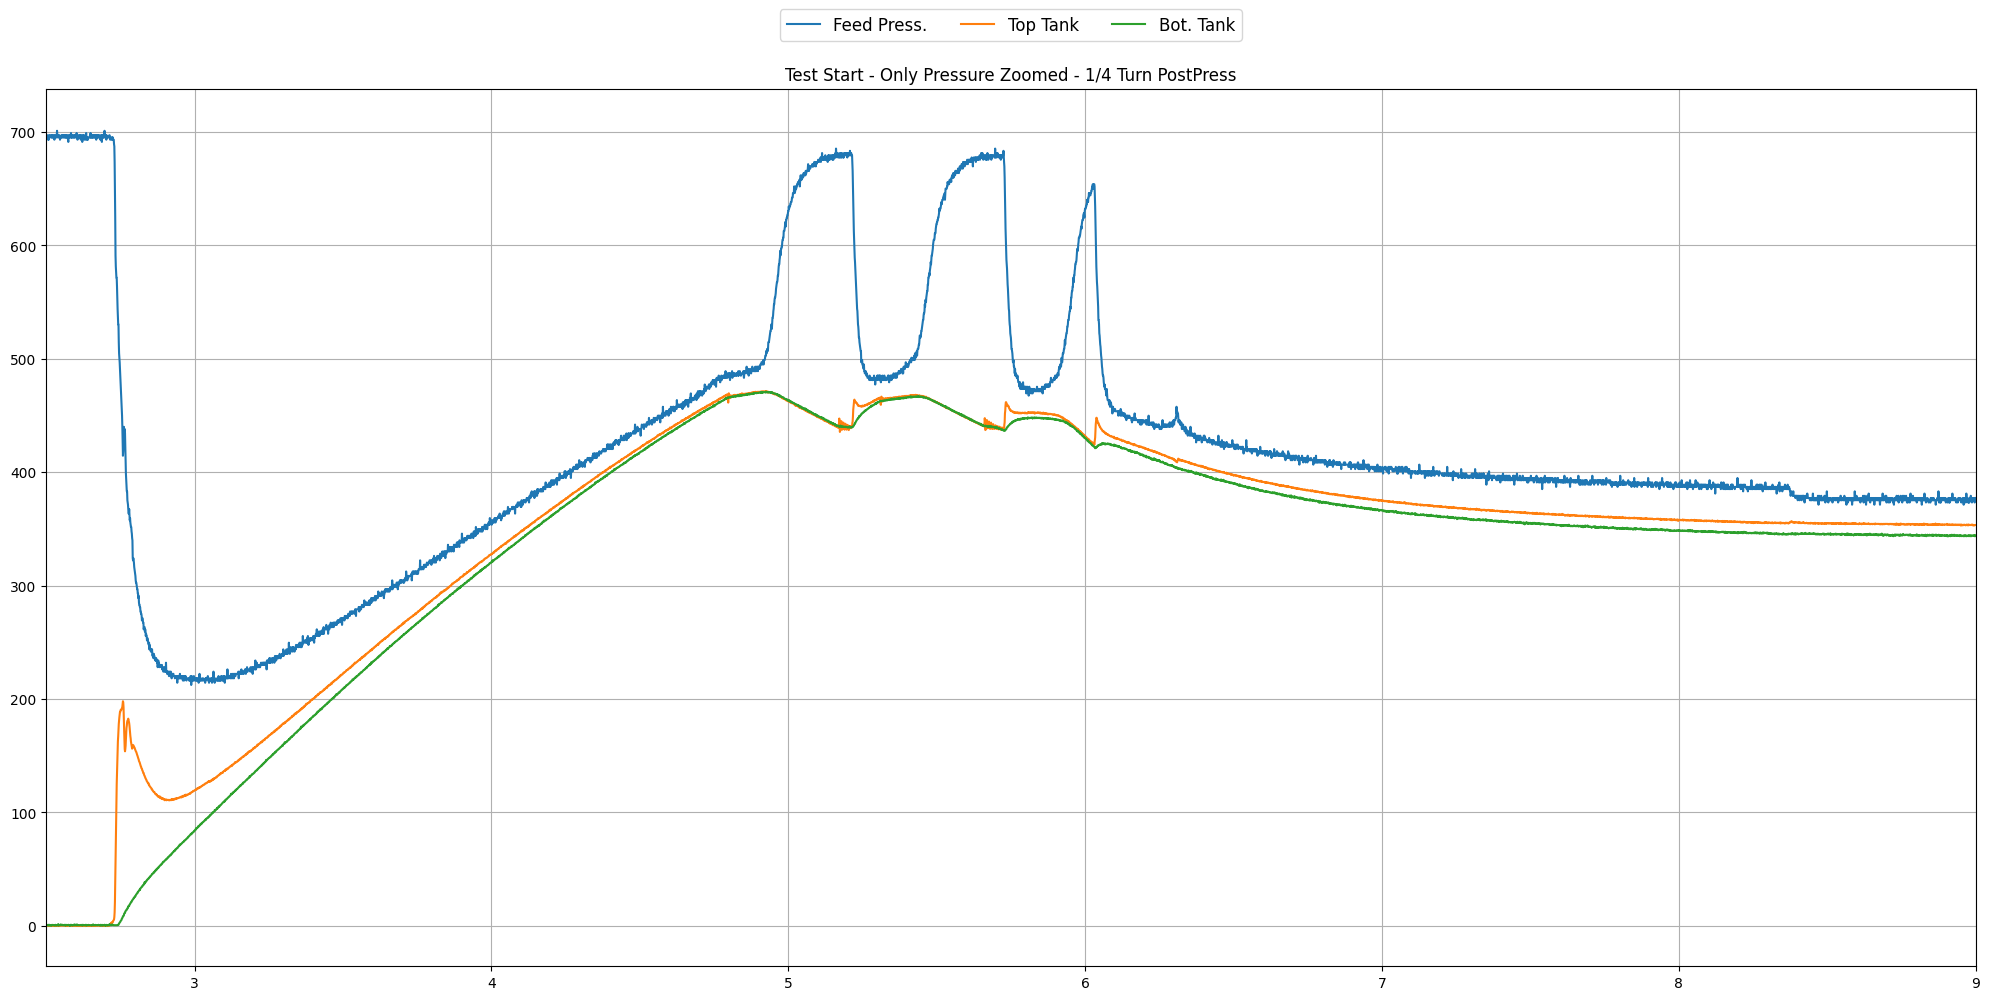

Plots saved to: ../8 - Plots


In [284]:
# Shared x-axis range
x_min = 0
x_max = max(ai_df["time_s"].max(), state_df["time_s"].max())

# === Zoom window ===
zoom_start = 2.5
zoom_end = 20.5

plot_width = 20
plot_height = 10

legend_ncol = 9
legend_fontsize = 12

# ============================================================
# Plot 1: Combined full-run plot
# ============================================================
fig, ax1 = plt.subplots(figsize=(plot_width, plot_height))

for col in ai_cols:
    ax1.plot(ai_df["time_s"], ai_df[col], label=ai_labels[col])

ax1.set_xlim(x_min, x_max)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Pressure (psi)")
ax1.set_title("Full Test All Channels - 1/4 Turn PostPress")
ax1.grid(True)

fig.canvas.draw()
y1_min, y1_max = ax1.get_ylim()
state_high = 0.95 * y1_max

for col in state_cols:
    state_plot = state_df[col] * state_high
    ax1.step(state_df["time_s"], state_plot, where="post", label=state_labels[col])

ax2 = ax1.twinx()
ax2.set_ylim(y1_min, y1_max)
ax2.set_ylabel("State")
ax2.set_yticks([0, state_high])
ax2.set_yticklabels(["0", "1"])

lines, labels = ax1.get_legend_handles_labels()
ax1.legend(
    lines,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=legend_ncol,
    fontsize=legend_fontsize
)

plt.tight_layout()
if save_plots:
    fig.savefig(os.path.join(output_folder, "Test_7_Plot_1.png"), dpi=300, bbox_inches="tight")
    #fig.savefig(os.path.join(output_folder, "plot_1_full_test_all_channels.pdf"), bbox_inches="tight")
plt.show()

# ============================================================
# Plot 2: Combined zoomed plot
# ============================================================
fig, ax1 = plt.subplots(figsize=(plot_width, plot_height))

for col in ai_cols:
    ax1.plot(ai_df["time_s"], ai_df[col], label=ai_labels[col])

ax1.set_xlim(zoom_start, zoom_end)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Pressure (psi)")
ax1.set_title("All Channels Zoomed - 1/4 Turn PostPress")
ax1.grid(True)

fig.canvas.draw()
y1_min_zoom, y1_max_zoom = ax1.get_ylim()
state_high_zoom = 0.95 * y1_max_zoom

for col in state_cols:
    state_plot = state_df[col] * state_high_zoom
    ax1.step(state_df["time_s"], state_plot, where="post", label=state_labels[col])

ax2 = ax1.twinx()
ax2.set_ylim(y1_min_zoom, y1_max_zoom)
ax2.set_ylabel("State")
ax2.set_yticks([0, state_high_zoom])
ax2.set_yticklabels(["0", "1"])

lines, labels = ax1.get_legend_handles_labels()
ax1.legend(
    lines,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=legend_ncol,
    fontsize=legend_fontsize
)

plt.tight_layout()
if save_plots:
    fig.savefig(os.path.join(output_folder, "Test_7_Plot_2.png"), dpi=300, bbox_inches="tight")
    #fig.savefig(os.path.join(output_folder, "plot_2_all_channels_zoomed.pdf"), bbox_inches="tight")
plt.show()

# ============================================================
# Plot 3: Analog-only full-run plot
# ============================================================
fig = plt.figure(figsize=(plot_width, plot_height))

for col in ai_cols:
    plt.plot(ai_df["time_s"], ai_df[col], label=ai_labels[col])

plt.xlim(x_min, x_max)
plt.xlabel("Time (s)")
plt.ylabel("Pressure (psi)")
plt.title("Full Test Only Pressure - 1/4 Turn PostPress")
plt.grid(True)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=min(len(ai_cols), legend_ncol),
    fontsize=legend_fontsize
)
plt.tight_layout()
if save_plots:
    fig.savefig(os.path.join(output_folder, "Test_7_Plot_3.png"), dpi=300, bbox_inches="tight")
    #fig.savefig(os.path.join(output_folder, "plot_3_full_test_only_pressure.pdf"), bbox_inches="tight")
plt.show()

# ============================================================
# Plot 4: Analog-only zoomed plot
# ============================================================
fig = plt.figure(figsize=(plot_width, plot_height))

for col in ai_cols:
    plt.plot(ai_df["time_s"], ai_df[col], label=ai_labels[col])

plt.xlim(zoom_start, zoom_end)
plt.xlabel("Time (s)")
plt.ylabel("Pressure (psi)")
plt.title("Only Pressure Zoomed - 1/4 Turn PostPress")
plt.grid(True)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=min(len(ai_cols), legend_ncol),
    fontsize=legend_fontsize
)
plt.tight_layout()
if save_plots:
    fig.savefig(os.path.join(output_folder, "Test_7_Plot_4.png"), dpi=300, bbox_inches="tight")
    #fig.savefig(os.path.join(output_folder, "plot_4_only_pressure_zoomed.pdf"), bbox_inches="tight")
plt.show()

# === Second zoom window for test start ===
zoom2_start = 2.5
zoom2_end = 9

# ============================================================
# Plot 5: Early-test zoom, pressure + state
# ============================================================
fig, ax1 = plt.subplots(figsize=(plot_width, plot_height))

for col in ai_cols:
    ax1.plot(ai_df["time_s"], ai_df[col], label=ai_labels[col])

ax1.set_xlim(zoom2_start, zoom2_end)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Pressure (psi)")
ax1.set_title("Test Start - All Channels Zoomed - 1/4 Turn PostPress")
ax1.grid(True)

fig.canvas.draw()
y2_min_zoom, y2_max_zoom = ax1.get_ylim()
state_high_zoom2 = 0.95 * y2_max_zoom

for col in state_cols:
    state_plot = state_df[col] * state_high_zoom2
    ax1.step(state_df["time_s"], state_plot, where="post", label=state_labels[col])

ax2 = ax1.twinx()
ax2.set_ylim(y2_min_zoom, y2_max_zoom)
ax2.set_ylabel("State")
ax2.set_yticks([0, state_high_zoom2])
ax2.set_yticklabels(["0", "1"])

lines, labels = ax1.get_legend_handles_labels()
ax1.legend(
    lines,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=legend_ncol,
    fontsize=legend_fontsize
)

plt.tight_layout()
if save_plots:
    fig.savefig(os.path.join(output_folder, "Test_7_Plot_5.png"), dpi=300, bbox_inches="tight")
    #fig.savefig(os.path.join(output_folder, "plot_5_test_start_all_channels.pdf"), bbox_inches="tight")
plt.show()

# ============================================================
# Plot 6: Early-test zoom, pressure only
# ============================================================
fig = plt.figure(figsize=(plot_width, plot_height))

for col in ai_cols:
    plt.plot(ai_df["time_s"], ai_df[col], label=ai_labels[col])

plt.xlim(zoom2_start, zoom2_end)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Pressure (psi)")
plt.title("Test Start - Only Pressure Zoomed - 1/4 Turn PostPress")
plt.grid(True)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=min(len(ai_cols), legend_ncol),
    fontsize=legend_fontsize
)

plt.tight_layout()
if save_plots:
    fig.savefig(os.path.join(output_folder, "Test_7_Plot_6.png"), dpi=300, bbox_inches="tight")
    #fig.savefig(os.path.join(output_folder, "plot_6_test_start_only_pressure.pdf"), bbox_inches="tight")
plt.show()

if save_plots:
    print(f"Plots saved to: {output_folder}")